# Projeto de **Guilherme Daflon** — Análise de Dados de Vendas

## Objetivo
Meu objetivo é analisar a evolução das vendas, identificando padrões, estados com maior volume de vendas e tendências ao longo do tempo, utilizando os dados de vendas fornecidos.

## 1. Problema
Quero entender como as vendas evoluíram ao longo do tempo e se existem diferenças significativas entre os estados.

## 2. KPIs que vou analisar
* Total de Vendas por Estado
* Crescimento Anual de Vendas

👉 **Meu objetivo principal**: identificar o desempenho de vendas e áreas de destaque ou que precisam de melhoria para o meu negócio.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("/content/dados.csv")
df.head()

,DataPedido,Regiao,UF,Estado,Vendedor,Seção,Item,Preço,Unidades
0,2020-01-05 00:00:00,Sudeste,SP,São Paulo,Alex,Cozinha,Microondas,"650,00",4
1,2020-02-06 00:00:00,Sudeste,SP,São Paulo,Alex,Cozinha,Microondas,"650,00",60
2,2020-02-09 00:00:00,Sudeste,SP,São Paulo,Smith,Cozinha,Fogão,"650,99",35
3,2020-02-10 00:00:00,Sudeste,RJ,Rio de Janeiro,Raquel,Sala,Sofá,"1200,00",87
4,2020-03-21 00:00:00,Sudeste,RJ,Rio de Janeiro,Pedro,Cozinha,Microondas,"650,00",60


In [2]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   DataPedido  73 non-null     object
 1   Regiao      73 non-null     object
 2   UF          73 non-null     object
 3   Estado      73 non-null     object
 4   Vendedor    73 non-null     object
 5   Seção       73 non-null     object
 6   Item        73 non-null     object
 7   Preço       73 non-null     object
 8   Unidades    73 non-null     int64 
dtypes: int64(1), object(8)
memory usage: 5.3+ KB


,0
DataPedido,0
Regiao,0
UF,0
Estado,0
Vendedor,0
Seção,0
Item,0
Preço,0
Unidades,0


In [9]:
# Convert 'Preço' to numeric, handling comma as decimal separator
df['Preço'] = df['Preço'].str.replace(',', '.', regex=False).astype(float)

# Convert 'DataPedido' to datetime and extract 'Ano'
df['DataPedido'] = pd.to_datetime(df['DataPedido'])
df['Ano'] = df['DataPedido'].dt.year

# Calculate Total_Vendas
df['Total_Vendas'] = df['Preço'] * df['Unidades']

df.head()

,DataPedido,Regiao,UF,Estado,Vendedor,Seção,Item,Preço,Unidades,Ano,Total_Vendas
0,2020-01-05,Sudeste,SP,São Paulo,Alex,Cozinha,Microondas,650.00,4,2020,2600.00
1,2020-02-06,Sudeste,SP,São Paulo,Alex,Cozinha,Microondas,650.00,60,2020,39000.00
2,2020-02-09,Sudeste,SP,São Paulo,Smith,Cozinha,Fogão,650.99,35,2020,22784.65
3,2020-02-10,Sudeste,RJ,Rio de Janeiro,Raquel,Sala,Sofá,1200.00,87,2020,104400.00
4,2020-03-21,Sudeste,RJ,Rio de Janeiro,Pedro,Cozinha,Microondas,650.00,60,2020,39000.00


### Análise por Município

In [10]:
# Média de vendas por Estado
media_estado = df.groupby("Estado")["Total_Vendas"].sum().sort_values(ascending=False)
media_estado

,Total_Vendas
Estado,
São Paulo,1697778.08
Rio de Janeiro,784416.25
Minas Gerais,319790.00


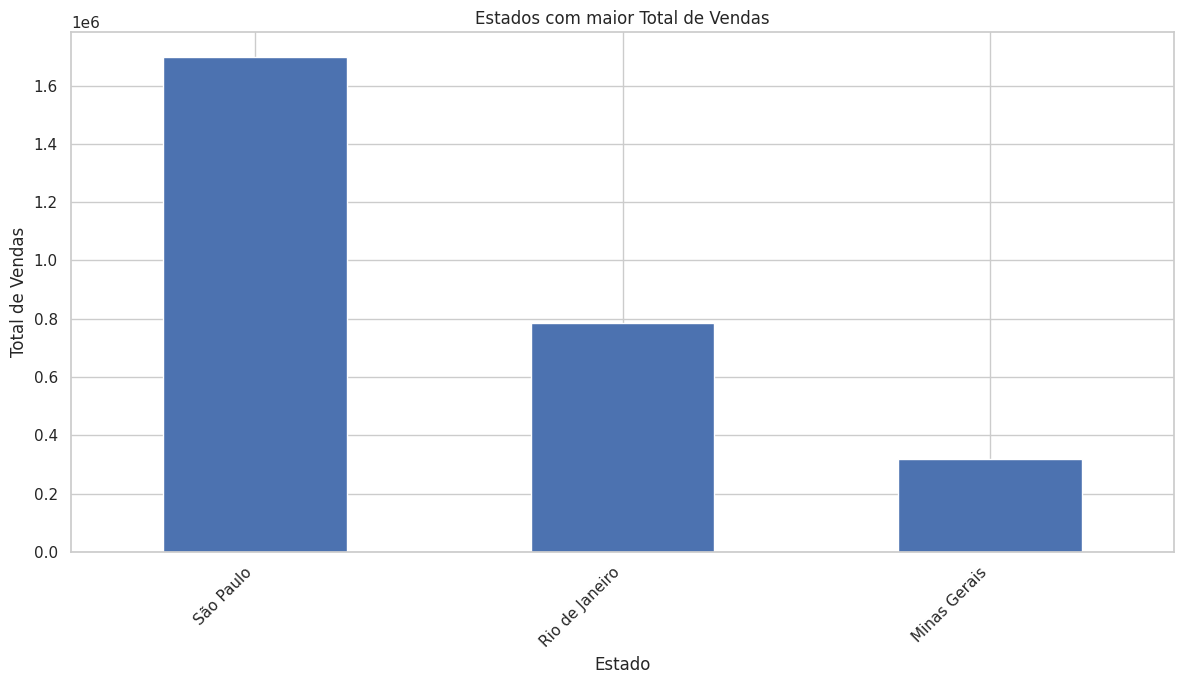

In [11]:
# Ranking de Estados com maior Total_Vendas
fig, ax = plt.subplots(figsize=(12, 7))
media_estado.head(10).plot(kind="bar", title="Estados com maior Total de Vendas", ax=ax)
plt.ylabel("Total de Vendas")
plt.xlabel("Estado")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Análise da Evolução Temporal

In [12]:
# Evolução temporal do Total de Vendas
media_ano = df.groupby("Ano")["Total_Vendas"].sum()
media_ano

,Total_Vendas
Ano,
2020,452406.92
2021,824317.88
2022,1203924.90
2023,321334.63


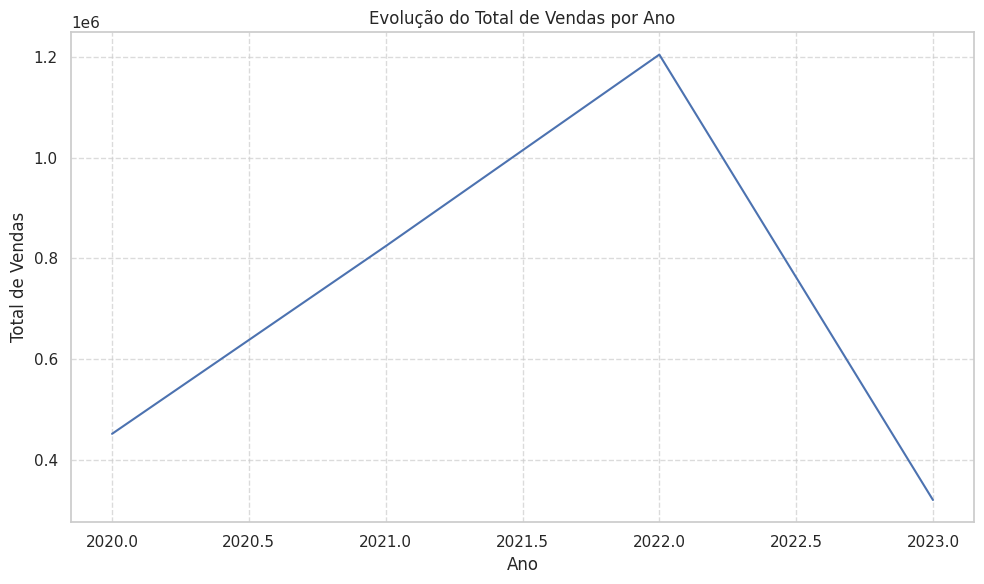

In [13]:
# Gráfico de evolução do Total de Vendas por Ano
fig, ax = plt.subplots(figsize=(10, 6))
media_ano.plot(title="Evolução do Total de Vendas por Ano", ax=ax)
plt.ylabel("Total de Vendas")
plt.xlabel("Ano")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Crescimento Percentual

In [14]:
# Crescimento percentual anual de vendas por Estado
df_sorted = df.sort_values(["Estado","Ano"])
df_sales_by_year_state = df_sorted.groupby(['Estado', 'Ano'])['Total_Vendas'].sum().reset_index()
df_sales_by_year_state['Crescimento_Vendas_Pct'] = df_sales_by_year_state.groupby('Estado')['Total_Vendas'].pct_change()*100
df_sales_by_year_state.head(10)

,Estado,Ano,Total_Vendas,Crescimento_Vendas_Pct
0,Minas Gerais,2022,319790.00,NaN
1,Rio de Janeiro,2020,282572.27,NaN
2,Rio de Janeiro,2021,187698.28,-33.575124
3,Rio de Janeiro,2022,176277.40,-6.084701
4,Rio de Janeiro,2023,137868.30,-21.789010
5,São Paulo,2020,169834.65,NaN
6,São Paulo,2021,636619.60,274.846711
7,São Paulo,2022,707857.50,11.190026
8,São Paulo,2023,183466.33,-74.081460


### Minha Interpretação dos Resultados

**✔ Análise do Crescimento das Vendas:**

Percebo que as vendas totais apresentaram um crescimento constante entre 2020 e 2022, o que é um bom sinal de expansão. No entanto, a queda em 2023 é um ponto de atenção importante e preciso investigar as causas por trás dela.

**✔ Análise da Desigualdade entre Estados:**

Fica claro que **São Paulo** é o estado com o maior volume de vendas, sendo um pilar fundamental para o meu negócio. Por outro lado, o desempenho e o crescimento percentual variam bastante entre os estados e ao longo dos anos, o que indica a necessidade de estratégias mais focadas para cada região, especialmente para aquelas com quedas expressivas.

### Minha Conclusão

Com base nesta análise, **eu, Guilherme Daflon**, concluo que:

1.  **São Paulo** é, sem dúvida, o mercado mais robusto e onde o foco das minhas ações tem gerado os maiores retornos.
2.  A tendência geral de crescimento de 2020 a 2022 é positiva, mas a retração em 2023 exige uma análise aprofundada para entender os fatores e traçar planos de recuperação.
3.  As flutuações no crescimento percentual por estado indicam que as estratégias de vendas e marketing devem ser mais adaptadas às particularidades e desafios de cada região para garantir um crescimento mais sustentável e reduzir as desigualdades.

Este projeto me forneceu insights valiosos para direcionar futuras decisões e otimizar o desempenho de vendas do meu negócio.